# Hyperparameter Learning Comparison: EFGP vs Vanilla GP vs SGPR vs SKI

Synthetic ground-truth data (SE kernel) — all methods start from the same initial hyperparameters.

In [1]:
import sys, time
import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

from efgpnd import EFGPND
from vanilla_gp_sampling import sample_gp_fast, sample_gp_rff
from kernels.squared_exponential import SquaredExponential
from utils.ski import fit_ski_gp
from utils.sgpr import fit_sgpr
from torch.optim import Adam

plt.rcParams['figure.dpi'] = 120
dtype = torch.float64
torch.manual_seed(42)

## Ground truth data

In [2]:
# --- Ground truth ---
true_ls = 0.05
true_var = 1
true_noise = 0.01
n = 100
d = 2  # set to 1 for 1D comparison

torch.manual_seed(42)
x = torch.rand(n, d, dtype=dtype)
y = sample_gp_rff(x, length_scale=true_ls, variance=true_var, num_features=5000, seed=42)
torch.manual_seed(1)
y = y + torch.sqrt(torch.tensor(true_noise, dtype=dtype)) * torch.randn(n, dtype=dtype)
print(f"Data: n={n}, d={d}, y std={y.std():.3f}")


Data: n=100, d=2, y std=0.929


## Common initial hyperparameters

In [3]:
init_ls = 0.3
init_var = 0.5
init_noise = 0.3
max_iters = 50
lr = 0.1
noise_floor = 1e-5

# EFGP frozen-grid refresh schedule:
#   pin the frequency grid (and the Hutchinson trace probes) for K iters, then
#   rebuild from current hypers. Lets the M-space CG warm starts actually apply
#   across iters. Set to None to rebuild every iter (legacy behavior).
refresh_grid_every = 5


## 1. EFGP

In [4]:
kernel_efgp = SquaredExponential(
    dimension=d, init_lengthscale=init_ls, init_variance=init_var
)
J = 1
EPSILON = 1e-4
cg_tol = 1e-5

training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
    'mean_cg_iters': [],
    'trace_cg_iters': [],
    'mtot': [],
    'feature_count': [],
    'grid_refreshed': [],
    'wall_sec': [],
}

model = EFGPND(x, y, kernel=kernel_efgp, sigmasq=init_noise, eps=EPSILON, estimate_params=False)
optimizer = Adam(model.parameters(), lr=lr)

# Log initial hyperparameters at iter 0
training_log['iter'].append(0)
training_log['lengthscale'].append(model.kernel.get_hyper('lengthscale'))
training_log['variance'].append(model.kernel.get_hyper('variance'))
training_log['sigmasq'].append(model._gp_params.sig2.item())
for k in ('mean_cg_iters', 'trace_cg_iters', 'mtot', 'feature_count', 'grid_refreshed', 'wall_sec'):
    training_log[k].append(None)

t0 = time.time()
for it in range(max_iters):
    t_iter = time.perf_counter()
    optimizer.zero_grad()
    model.compute_gradients(
        trace_samples=J, cg_tol=cg_tol, noise_floor=noise_floor,
        refresh_grid_every=refresh_grid_every,
    )
    optimizer.step()
    dt = time.perf_counter() - t_iter

    stats = model.last_gradient_stats
    mean_cg_iters = stats.get('mean_cg_iters')
    trace_cg_iters = stats.get('trace_cg_iters')
    mtot = stats.get('mtot')
    feature_count = stats.get('feature_count')
    refreshed = stats.get('grid_refreshed')

    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it + 1)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)
    training_log['mean_cg_iters'].append(mean_cg_iters)
    training_log['trace_cg_iters'].append(trace_cg_iters)
    training_log['mtot'].append(mtot)
    training_log['feature_count'].append(feature_count)
    training_log['grid_refreshed'].append(refreshed)
    training_log['wall_sec'].append(dt)

    if it % 10 == 0:
        flag = '*' if refreshed else (' ' if refreshed is False else '-')
        print(
            f"{flag} iter {it:>3}  {dt:5.2f}s  "
            f"ℓ={lengthscale:.4g}  σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}  "
            f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}  mtot={mtot}  M={feature_count}"
        )

efgp_time = time.time() - t0
print(
    f"Final: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}, "
    f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}, mtot={mtot}, M={feature_count}"
)
print(f"EFGP fit time: {efgp_time:.2f}s  (refresh_grid_every={refresh_grid_every})")
walls = [w for w in training_log['wall_sec'] if w is not None]
if refresh_grid_every:
    rf = [w for w, r in zip(walls, training_log['grid_refreshed'][1:]) if r]
    wm = [w for w, r in zip(walls, training_log['grid_refreshed'][1:]) if r is False]
    if rf and wm:
        print(f"  refresh iters (n={len(rf)}): mean {sum(rf)/len(rf):.2f}s")
        print(f"  warm iters    (n={len(wm)}): mean {sum(wm)/len(wm):.2f}s")


* iter   0   0.05s  ℓ=0.275  σ_f²=0.5405  σ_n²=0.3269  cg(mean/trace)=8/9  mtot=13  M=169
* iter  10   0.04s  ℓ=0.1182  σ_f²=0.8848  σ_n²=0.6105  cg(mean/trace)=13/13  mtot=19  M=361
* iter  20   0.04s  ℓ=0.06519  σ_f²=0.5212  σ_n²=0.6574  cg(mean/trace)=11/12  mtot=31  M=961
* iter  30   0.06s  ℓ=0.04831  σ_f²=0.3533  σ_n²=0.5288  cg(mean/trace)=10/11  mtot=39  M=1521
* iter  40   0.05s  ℓ=0.06303  σ_f²=0.4006  σ_n²=0.4139  cg(mean/trace)=12/13  mtot=33  M=1089
Final: ℓ=0.07459, σ_f²=0.6671, σ_n²=0.3432, cg(mean/trace)=10/12, mtot=29, M=841
EFGP fit time: 0.90s  (refresh_grid_every=5)
  refresh iters (n=10): mean 0.05s
  warm iters    (n=40): mean 0.01s


## 2. Vanilla (Exact) GP via GPyTorch

In [5]:
class _ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.base_kernel = gpytorch.kernels.RBFKernel()
        self.covar_module = gpytorch.kernels.ScaleKernel(self.base_kernel)

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), self.covar_module(x)
        )


def fit_exact_gp(x, y, *, max_iters=50, lr=0.1,
                 init_lengthscale=None, init_outputscale=None, init_noise=None,
                 verbose=True):
    tx = x.to(dtype=torch.float64).contiguous()
    ty = y.to(dtype=torch.float64).contiguous()

    lik = gpytorch.likelihoods.GaussianLikelihood().to(dtype=torch.float64)
    model = _ExactGPModel(tx, ty, lik).to(dtype=torch.float64)

    with torch.no_grad():
        if init_lengthscale is not None:
            model.base_kernel.lengthscale = float(init_lengthscale)
        if init_outputscale is not None:
            model.covar_module.outputscale = float(init_outputscale)
        if init_noise is not None:
            lik.noise = float(init_noise)

    model.train(); lik.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(lik, model)

    history = dict(iteration=[], loss=[], lengthscale=[], outputscale=[], noise=[], elapsed_sec=[])
    t0 = time.time()

    # Log initial hyperparameters at iter 0
    history['iteration'].append(0)
    history['loss'].append(float('nan'))
    history['lengthscale'].append(float(model.base_kernel.lengthscale.detach().mean()))
    history['outputscale'].append(float(model.covar_module.outputscale.detach()))
    history['noise'].append(float(lik.noise.detach()))
    history['elapsed_sec'].append(0.0)

    for i in range(max_iters):
        opt.zero_grad(set_to_none=True)
        loss = -mll(model(tx), ty)
        loss.backward()
        opt.step()

        history['iteration'].append(i + 1)
        history['loss'].append(float(loss.detach()))
        history['lengthscale'].append(float(model.base_kernel.lengthscale.detach().mean()))
        history['outputscale'].append(float(model.covar_module.outputscale.detach()))
        history['noise'].append(float(lik.noise.detach()))
        history['elapsed_sec'].append(time.time() - t0)

        if verbose and (i % 10 == 0 or i == max_iters - 1):
            print(f"[Exact] iter {i+1:>3}/{max_iters}  loss={history['loss'][-1]:.6g}  "
                  f"ls={history['lengthscale'][-1]:.6g}  os={history['outputscale'][-1]:.6g}  "
                  f"noise={history['noise'][-1]:.6g}")

    fit_time = time.time() - t0
    model.eval(); lik.eval()
    return {'history': history, 'fit_time_sec': fit_time, 'model': model, 'likelihood': lik}


exact_result = fit_exact_gp(
    x, y, max_iters=max_iters, lr=lr,
    init_lengthscale=init_ls, init_outputscale=init_var, init_noise=init_noise,
)
exact_hist = exact_result['history']
exact_time = exact_result['fit_time_sec']
print(f"Exact GP fit time: {exact_time:.2f}s")

[Exact] iter   1/50  loss=1.66068  ls=0.275026  os=0.540548  noise=0.326886
[Exact] iter  11/50  loss=1.33147  ls=0.1141  os=0.780133  noise=0.61365
[Exact] iter  21/50  loss=1.29928  ls=0.059994  os=0.405627  noise=0.671828
[Exact] iter  31/50  loss=1.28792  ls=0.0472042  os=0.291514  noise=0.562344
[Exact] iter  41/50  loss=1.25989  ls=0.0512984  os=0.48666  noise=0.439142
[Exact] iter  50/50  loss=1.24005  ls=0.0567692  os=0.607175  noise=0.329865
Exact GP fit time: 0.10s


## 3. SKI

In [6]:
ski_result = fit_ski_gp(
    x, y, kernel='SE', max_iters=max_iters, lr=lr,
    init_lengthscale=init_ls, init_outputscale=init_var, init_noise=init_noise, num_trace_samples=J,
    dtype=torch.float32, verbose=True,
)
ski_hist = ski_result['history']
ski_time = ski_result['fit_time_sec']
print(f"SKI fit time: {ski_time:.2f}s  grid={ski_result['grid_size']}")


/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/linear_operator/utils/sparse.py:51: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if nonzero_indices.storage():
/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/linear_operator/utils/sparse.py:66: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:646.)
  res = cls(index_tensor, value_tensor, interp_size)


[SKI] iter   1/50  loss=1.51012  ls=0.326894  os=0.461837  noise=0.326886  time(fwd/bwd)=0.15/0.02s  rss=0.349 GB
[SKI] iter   2/50  loss=1.53565  ls=0.349313  os=0.427017  noise=0.355655  time(fwd/bwd)=0.08/0.02s  rss=0.351 GB
[SKI] iter   3/50  loss=1.45359  ls=0.375868  os=0.393931  noise=0.385584  time(fwd/bwd)=0.08/0.02s  rss=0.352 GB
[SKI] iter   4/50  loss=1.34536  ls=0.405666  os=0.366359  noise=0.416574  time(fwd/bwd)=0.08/0.02s  rss=0.352 GB
[SKI] iter   5/50  loss=1.30769  ls=0.431929  os=0.346735  noise=0.448861  time(fwd/bwd)=0.08/0.02s  rss=0.354 GB
[SKI] iter   6/50  loss=1.28345  ls=0.450808  os=0.335039  noise=0.483516  time(fwd/bwd)=0.08/0.02s  rss=0.354 GB
[SKI] iter   7/50  loss=1.31738  ls=0.464726  os=0.322864  noise=0.515322  time(fwd/bwd)=0.08/0.02s  rss=0.355 GB
[SKI] iter   8/50  loss=1.28546  ls=0.474422  os=0.313957  noise=0.546875  time(fwd/bwd)=0.08/0.02s  rss=0.356 GB
[SKI] iter   9/50  loss=1.26702  ls=0.482017  os=0.309088  noise=0.577556  time(fwd/bwd)

## 4. SGPR (varying inducing points)


In [7]:
sgpr_Ms = [50,250,1000]
sgpr_results = {}

for m in sgpr_Ms:
    print(f"\n--- SGPR M={m} ---")
    result = fit_sgpr(
        x, y, kernel='SE', num_inducing=m,
        max_iters=max_iters, lr=lr,
        init_lengthscale=init_ls, init_outputscale=init_var, init_noise=init_noise,
        dtype=dtype, verbose=False,
    )
    sgpr_results[m] = result
    print(f"SGPR M={m} fit time: {result['fit_time_sec']:.2f}s")
    h = result['history']
    print(f"  final: ls={h['lengthscale'][-1]:.4f}, os={h['outputscale'][-1]:.4f}, noise={h['noise'][-1]:.4f}")



--- SGPR M=50 ---
SGPR M=50 fit time: 0.58s
  final: ls=0.0935, os=0.2212, noise=0.6730

--- SGPR M=250 ---
SGPR M=250 fit time: 0.60s
  final: ls=0.0866, os=0.3692, noise=0.5707

--- SGPR M=1000 ---
SGPR M=1000 fit time: 0.30s
  final: ls=0.0923, os=0.3461, noise=0.5929


## Learning curves

In [8]:
# # Compute exact log marginal likelihood on a grid (lengthscale vs variance)
# # Fix noise at true_noise to get a 2D slice
# grid_res = 60
# ls_grid = torch.linspace(0.02, 0.6, grid_res, dtype=torch.float64)
# var_grid = torch.linspace(0.2, 4.0, grid_res, dtype=torch.float64)
# log_marg_grid = torch.zeros(grid_res, grid_res)

# x_f64 = x.to(torch.float64)
# y_f64 = y.to(torch.float64)

# for i, ls_val in enumerate(ls_grid):
#     for j, var_val in enumerate(var_grid):
#         k = SquaredExponential(dimension=d, init_lengthscale=float(ls_val), init_variance=float(var_val))
#         log_marg_grid[i, j] = k.log_marginal(x_f64, y_f64, float(true_noise))

# print(f"Log marginal grid: min={log_marg_grid.min():.1f}, max={log_marg_grid.max():.1f}")


In [9]:
# # --- Figure: contour plot + learning curves ---
# fig = plt.figure(figsize=(18, 5))

# # Left panel: log marginal contour with optimization paths
# ax_contour = fig.add_subplot(1, 4, 1)

# # Contour of log marginal
# lm = log_marg_grid.numpy()
# lm_clipped = np.clip(lm, lm.max() - 150, lm.max())
# levels = np.linspace(lm_clipped.min(), lm_clipped.max(), 30)

# cf = ax_contour.contourf(ls_grid.numpy(), var_grid.numpy(), lm_clipped.T,
#                          levels=levels, cmap='viridis', extend='both')
# ax_contour.contour(ls_grid.numpy(), var_grid.numpy(), lm_clipped.T,
#                    levels=levels, colors='k', linewidths=0.3, alpha=0.4)

# # Optimization paths (lengthscale vs variance)
# def plot_path(ax, ls_list, var_list, color, label, marker='o', ms=3, zorder=10):
#     ax.plot(ls_list, var_list, '-', color=color, lw=1.5, alpha=0.8, zorder=zorder)
#     ax.scatter(ls_list[0], var_list[0], color=color, s=60, marker='s',
#                edgecolors='white', linewidths=0.8, zorder=zorder+1)
#     ax.scatter(ls_list[-1], var_list[-1], color=color, s=60, marker='D',
#                edgecolors='white', linewidths=0.8, zorder=zorder+1, label=label)

# plot_path(ax_contour, training_log['lengthscale'], training_log['variance'],
#           'dodgerblue', 'EFGP')
# plot_path(ax_contour, exact_hist['lengthscale'], exact_hist['outputscale'],
#           'lime', 'Exact GP')
# plot_path(ax_contour, ski_hist['lengthscale'], ski_hist['outputscale'],
#           'white', 'SKI')

# sgpr_colors = ['red', 'orange']
# for (m, res), c in zip(sgpr_results.items(), sgpr_colors):
#     h = res['history']
#     plot_path(ax_contour, h['lengthscale'], h['outputscale'], c, f'SGPR M={m}')

# # True value
# ax_contour.scatter(true_ls, true_var, color='yellow', s=120, marker='*',
#                    edgecolors='black', linewidths=1, zorder=20, label='True')

# ax_contour.set_xlabel('Lengthscale')
# ax_contour.set_ylabel('Variance')
# ax_contour.set_title(f'Log marginal (noise={true_noise})')
# ax_contour.legend(fontsize=6, loc='upper right')
# fig.colorbar(cf, ax=ax_contour, shrink=0.8, pad=0.02)

# # Right 3 panels: parameter vs iteration
# param_specs = [
#     ('Lengthscale', 'lengthscale', 'lengthscale', true_ls),
#     ('Variance', 'variance', 'outputscale', true_var),
#     ('Noise', 'sigmasq', 'noise', true_noise),
# ]

# efgp_iters = training_log['iter']

# for idx, (title, efgp_key, gpy_key, true_val) in enumerate(param_specs):
#     ax = fig.add_subplot(1, 4, idx + 2)

#     ax.plot(efgp_iters, training_log[efgp_key],
#             '-', color='dodgerblue', lw=1.5, label='EFGP')
#     ax.plot(exact_hist['iteration'], exact_hist[gpy_key],
#             '-', color='lime', lw=1.5, label='Exact GP')
#     ax.plot(ski_hist['iteration'], ski_hist[gpy_key],
#             '-', color='gray', lw=1.5, label='SKI')

#     for (m, res), c in zip(sgpr_results.items(), sgpr_colors):
#         h = res['history']
#         ax.plot(h['iteration'], h[gpy_key],
#                 '--', color=c, lw=1.5, label=f'SGPR M={m}')

#     ax.axhline(true_val, color='black', ls=':', lw=1, alpha=0.6, label='True')
#     ax.set_xlabel('Iteration')
#     ax.set_title(title)
#     if idx == 0:
#         ax.legend(fontsize=6)

# fig.suptitle(f'Hyperparameter Learning (n={n}, d={d})', fontsize=13)
# fig.tight_layout()
# plt.show()


## Scale up: n = 50,000

Sample from the spectral approximation (Cholesky is O(n³) at this scale).

In [16]:
n_big = 250_000
n_feat_rff = 500
torch.manual_seed(1)
x_big = torch.rand(n_big, d, dtype=dtype)

sampler = "efgpnd"  # "rff" or "efgpnd"
sampler_eps = 1e-4   # only used when sampler == "efgpnd"

if sampler == "rff":
    f_big = sample_gp_rff(
        x_big, length_scale=true_ls, variance=true_var,
        num_features=n_feat_rff, seed=0,
    )
elif sampler == "efgpnd":
    from efgpnd import sample_gp_efgpnd
    true_kernel = SquaredExponential(
        dimension=d, init_lengthscale=true_ls, init_variance=true_var,
    )
    f_big = sample_gp_efgpnd(x_big, kernel=true_kernel, eps=sampler_eps, seed=0)
else:
    raise ValueError(f"unknown sampler: {sampler}")

torch.manual_seed(1)
y_big = f_big + torch.sqrt(torch.tensor(true_noise, dtype=dtype)) * torch.randn(n_big, dtype=dtype)
print(f"Big data: n={n_big}, sampler={sampler}, y std={y_big.std():.3f}")

Big data: n=250000, sampler=efgpnd, y std=0.911


In [55]:
lr = 0.3
epsilon_list = [1e-4,]#, 1e-5, 1e-6]
max_iters = 300
J=1
precond = "kronecker"
use_precond = True
refresh_grid_every = 10

# cg_tol is tied to EPSILON: cg_tol = 0.1 * EPSILON
init_ls = 0.3
init_var = .5


In [56]:
# --- EFGP: sweep over EPSILON (with cg_tol = 0.1 * EPSILON) ---
efgp_results_big = {}

for EPSILON in epsilon_list:
    # cg_tol = 0.1 * EPSILON
    cg_tol = 1e-5
    
    print(f"\n--- EFGP EPSILON={EPSILON:.0e}, cg_tol={cg_tol:.0e}, refresh_grid_every={refresh_grid_every} ---")

    kernel_efgp_big = SquaredExponential(
        dimension=d, init_lengthscale=init_ls, init_variance=init_var
    )

    training_log_eps = {
        'iter': [], 'lengthscale': [], 'variance': [], 'sigmasq': [],
        'grid_refreshed': [], 'wall_sec': [],
    }

    model_eps = EFGPND(x_big, y_big, kernel=kernel_efgp_big,
                       sigmasq=0.3, eps=EPSILON, estimate_params=False,opts={"mean_cg_preconditioner_type":precond,"trace_cg_preconditioner":use_precond,"mean_cg_preconditioner":use_precond})
    optimizer_eps = Adam(model_eps.parameters(), lr=lr)

    training_log_eps['iter'].append(0)
    training_log_eps['lengthscale'].append(model_eps.kernel.get_hyper('lengthscale'))
    training_log_eps['variance'].append(model_eps.kernel.get_hyper('variance'))
    training_log_eps['sigmasq'].append(model_eps._gp_params.sig2.item())
    training_log_eps['grid_refreshed'].append(None)
    training_log_eps['wall_sec'].append(None)

    t0 = time.time()
    for it in range(max_iters):
        t_iter = time.perf_counter()
        optimizer_eps.zero_grad()
        model_eps.compute_gradients(
            trace_samples=J, cg_tol=cg_tol, noise_floor=noise_floor,
            refresh_grid_every=refresh_grid_every,
        )
        optimizer_eps.step()
        dt = time.perf_counter() - t_iter

        refreshed = model_eps.last_gradient_stats.get('grid_refreshed')
        ls = model_eps.kernel.get_hyper('lengthscale')
        var = model_eps.kernel.get_hyper('variance')
        sig = model_eps._gp_params.sig2.item()
        training_log_eps['iter'].append(it + 1)
        training_log_eps['lengthscale'].append(ls)
        training_log_eps['variance'].append(var)
        training_log_eps['sigmasq'].append(sig)
        training_log_eps['grid_refreshed'].append(refreshed)
        training_log_eps['wall_sec'].append(dt)

        if it % 10 == 0:
            flag = '*' if refreshed else (' ' if refreshed is False else '-')
            print(f"  {flag} iter {it:>3}  {dt:5.2f}s  l={ls:.4g}  sf2={var:.4g}  sn2={sig:.4g}")

    fit_time = time.time() - t0
    print(f"  Final: l={ls:.4g}, sf2={var:.4g}, sn2={sig:.4g}")
    print(f"  fit time: {fit_time:.2f}s")
    walls = [w for w in training_log_eps['wall_sec'] if w is not None]
    if refresh_grid_every and walls:
        rf = [w for w, r in zip(walls, training_log_eps['grid_refreshed'][1:]) if r]
        wm = [w for w, r in zip(walls, training_log_eps['grid_refreshed'][1:]) if r is False]
        if rf and wm:
            print(f"  refresh iters (n={len(rf)}): mean {sum(rf)/len(rf):.2f}s")
            print(f"  warm iters    (n={len(wm)}): mean {sum(wm)/len(wm):.2f}s")

    efgp_results_big[EPSILON] = {
        'model': model_eps,
        'training_log': training_log_eps,
        'fit_time': fit_time,
        'cg_tol': cg_tol,
    }

# Aliases for downstream cells that expect the "default" EFGP run (use smallest EPSILON).
_default_eps = min(epsilon_list)
model_big = efgp_results_big[_default_eps]['model']
training_log_big = efgp_results_big[_default_eps]['training_log']
efgp_time_big = efgp_results_big[_default_eps]['fit_time']



--- EFGP EPSILON=1e-04, cg_tol=1e-05, refresh_grid_every=10 ---
  * iter   0   0.06s  l=0.2305  sf2=0.629  sn2=0.3868
  * iter  10   0.06s  l=0.04338  sf2=2.558  sn2=0.3088
  * iter  20   0.09s  l=0.03291  sf2=3.736  sn2=0.02178
  * iter  30   0.07s  l=0.04949  sf2=4.044  sn2=0.005356
  * iter  40   0.11s  l=0.05546  sf2=4.138  sn2=0.01554
  * iter  50   0.09s  l=0.05246  sf2=4.166  sn2=0.01005
  * iter  60   0.09s  l=0.05518  sf2=4.126  sn2=0.008971
  * iter  70   0.09s  l=0.05359  sf2=4.075  sn2=0.01106
  * iter  80   0.09s  l=0.0541  sf2=4  sn2=0.009421
  * iter  90   0.08s  l=0.05502  sf2=3.925  sn2=0.0102
  * iter 100   0.08s  l=0.05431  sf2=3.857  sn2=0.009921
  * iter 110   0.09s  l=0.0546  sf2=3.784  sn2=0.009954
  * iter 120   0.09s  l=0.05445  sf2=3.71  sn2=0.01
  * iter 130   0.09s  l=0.05431  sf2=3.632  sn2=0.009942
  * iter 140   0.09s  l=0.05436  sf2=3.55  sn2=0.00999
  * iter 150   0.09s  l=0.0542  sf2=3.465  sn2=0.009957
  * iter 160   0.09s  l=0.05414  sf2=3.376  sn2=

In [13]:
# --- SKI ---
ski_result_big = fit_ski_gp(
    x_big, y_big, kernel='SE', max_iters=max_iters, lr=lr,
    init_lengthscale=init_ls, init_outputscale=init_var, init_noise=init_noise,
    dtype=torch.float32, verbose=True, num_trace_samples=J,cg_tolerance=1
)
ski_hist_big = ski_result_big['history']
ski_time_big = ski_result_big['fit_time_sec']
print(f"SKI (n={n_big}) fit time: {ski_time_big:.2f}s")


KeyboardInterrupt: 

In [ ]:
# --- SGPR ---
sgpr_results_big = {}
sgpr_Ms = [50,250,1000]
for m in sgpr_Ms:
    print(f"--- SGPR M={m} (n={n_big}) ---")
    res = fit_sgpr(
        x_big, y_big, kernel='SE', num_inducing=m,
        max_iters=max_iters, lr=lr/5,
        init_lengthscale=init_ls, init_outputscale=init_var, init_noise=init_noise,
        dtype=dtype, verbose=True,
    )
    sgpr_results_big[m] = res
    h = res['history']
    t = res['fit_time_sec']
    hl = h['lengthscale'][-1]
    ho = h['outputscale'][-1]
    hn = h['noise'][-1]
    print(f"  time={t:.2f}s  final: ls={hl:.4f}, os={ho:.4f}, noise={hn:.4f}")


--- SGPR M=50 (n=250000) ---
[SGPR M=50] iter   1/50  loss=1.46753  ls=0.256367  os=0.574735  noise=0.349838
[SGPR M=50] iter   2/50  loss=1.32182  ls=0.221845  os=0.649975  noise=0.40457
[SGPR M=50] iter   3/50  loss=1.2284  ls=0.195606  os=0.72337  noise=0.462082
[SGPR M=50] iter   4/50  loss=1.19143  ls=0.177453  os=0.785241  noise=0.520409
[SGPR M=50] iter   5/50  loss=1.27692  ls=0.170059  os=0.796258  noise=0.581678
[SGPR M=50] iter   6/50  loss=1.27069  ls=0.169718  os=0.774399  noise=0.643974
[SGPR M=50] iter   7/50  loss=1.28446  ls=0.175212  os=0.732966  noise=0.705913
[SGPR M=50] iter   8/50  loss=1.29604  ls=0.184584  os=0.684496  noise=0.765958
[SGPR M=50] iter   9/50  loss=1.25694  ls=0.195723  os=0.635978  noise=0.819888
[SGPR M=50] iter  10/50  loss=1.25834  ls=0.20752  os=0.591663  noise=0.865901
[SGPR M=50] iter  11/50  loss=1.27867  ls=0.220328  os=0.550789  noise=0.904361
[SGPR M=50] iter  12/50  loss=1.27955  ls=0.234059  os=0.51431  noise=0.934454
[SGPR M=50] iter

/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


[SGPR M=250] iter   1/50  loss=1.44838  ls=0.256367  os=0.574735  noise=0.349838
[SGPR M=250] iter   2/50  loss=1.23701  ls=0.218634  os=0.656266  noise=0.402319
[SGPR M=250] iter   3/50  loss=1.09161  ls=0.186509  os=0.743046  noise=0.452045
[SGPR M=250] iter   4/50  loss=0.992075  ls=0.159053  os=0.834603  noise=0.491922
[SGPR M=250] iter   5/50  loss=0.895916  ls=0.135237  os=0.932376  noise=0.514466
[SGPR M=250] iter   6/50  loss=0.806069  ls=0.115193  os=1.03346  noise=0.517784
[SGPR M=250] iter   7/50  loss=0.766295  ls=0.099351  os=1.13227  noise=0.506028
[SGPR M=250] iter   8/50  loss=0.767965  ls=0.0879892  os=1.21868  noise=0.484423
[SGPR M=250] iter   9/50  loss=0.788753  ls=0.0806353  os=1.27312  noise=0.457274
[SGPR M=250] iter  10/50  loss=0.820017  ls=0.0773506  os=1.27671  noise=0.427838
[SGPR M=250] iter  11/50  loss=0.851209  ls=0.0773317  os=1.24296  noise=0.398641
[SGPR M=250] iter  12/50  loss=0.895025  ls=0.0803639  os=1.18242  noise=0.371887
[SGPR M=250] iter  13

NameError: name 'sgpr_results_big' is not defined

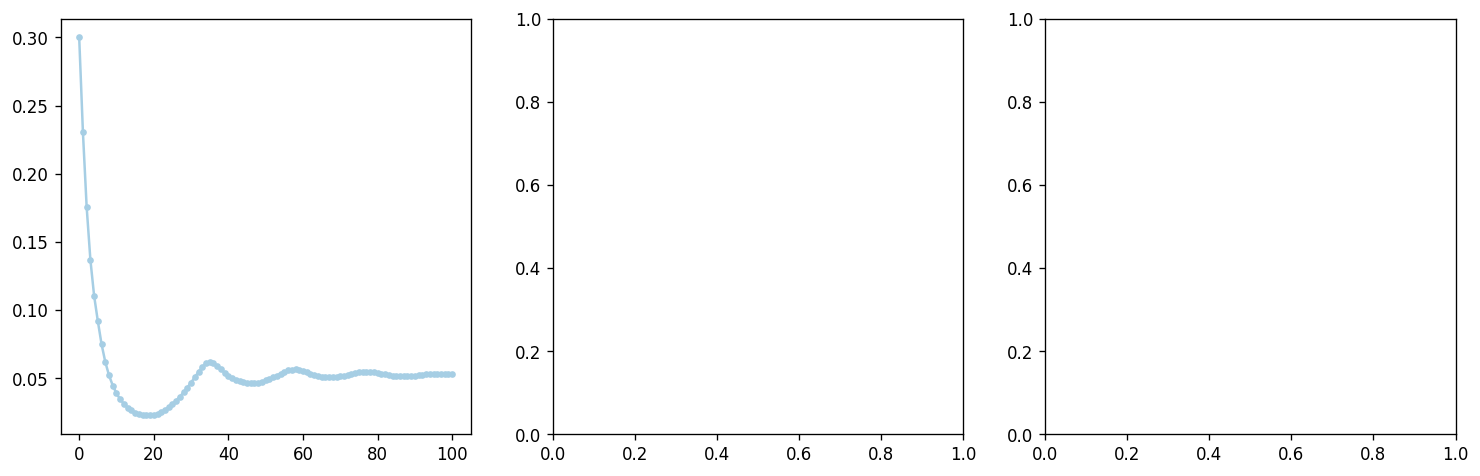

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sgpr_colors = ['r', 'orange', 'purple', 'brown']
param_specs = [
    ('Lengthscale', 'lengthscale', 'lengthscale', true_ls),
    ('Variance', 'variance', 'outputscale', true_var),
    ('Noise', 'sigmasq', 'noise', true_noise),
]

# Colormap for EFGP EPSILON sweep (larger eps -> lighter blue)
efgp_eps_sorted = sorted(efgp_results_big.keys(), reverse=True)
efgp_cmap = plt.cm.Blues
efgp_colors = [efgp_cmap(0.35 + 0.6 * i / max(1, len(efgp_eps_sorted) - 1))
               for i in range(len(efgp_eps_sorted))]

for ax, (title, efgp_key, gpy_key, true_val) in zip(axes, param_specs):
    for eps, c in zip(efgp_eps_sorted, efgp_colors):
        res = efgp_results_big[eps]
        log = res['training_log']
        ax.plot(log['iter'], log[efgp_key],
                '-o', color=c, ms=3,
                label=f'EFGP eps={eps:.0e} ({res["fit_time"]:.1f}s)')

    for (m, res), c in zip(sgpr_results_big.items(), sgpr_colors):
        h = res['history']
        ax.plot(h['iteration'], h[gpy_key],
                '--', color=c, ms=3,
                label=f'SGPR M={m} ({res["fit_time_sec"]:.1f}s)')

    ax.plot(ski_hist_big['iteration'], ski_hist_big[gpy_key],
            '-', color='gray', lw=1.5, ms=3,
            label=f'SKI ({ski_time_big:.1f}s)')

    ax.axhline(true_val, color='gray', ls=':', lw=1.5, label='True')
    ax.set_xlabel('Iteration')
    ax.set_title(title)
    ax.legend(fontsize=6)

fig.suptitle(f'Hyperparameter Learning Comparison (n={n_big})', fontsize=13)
fig.tight_layout()
plt.show()

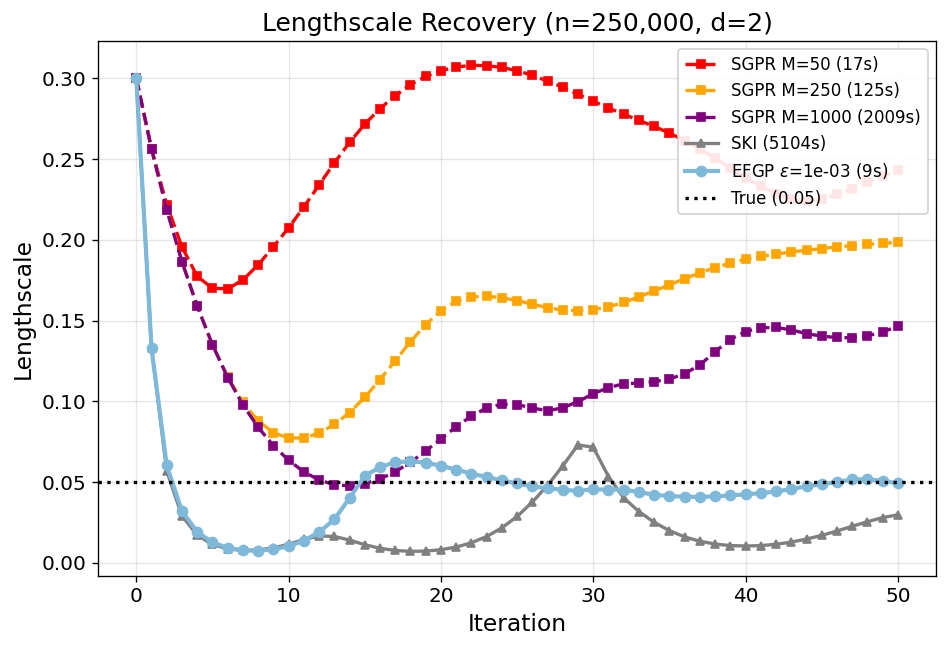

In [ ]:
# --- Lengthscale learning curve (presentation figure) ---
fig, ax = plt.subplots(figsize=(8, 5.5))

sgpr_colors_ls = ['red', 'orange', 'purple', 'brown']
efgp_eps_sorted_ls = sorted(efgp_results_big.keys(), reverse=True)
efgp_cmap_ls = plt.cm.Blues
efgp_colors_ls = [efgp_cmap_ls(0.45 + 0.5 * i / max(1, len(efgp_eps_sorted_ls) - 1))
                  for i in range(len(efgp_eps_sorted_ls))]

for (m, res), c in zip(sgpr_results_big.items(), sgpr_colors_ls):
    h = res['history']
    ax.plot(h['iteration'], h['lengthscale'],
            '--s', color=c, ms=5, lw=2,
            label=f'SGPR M={m} ({res["fit_time_sec"]:.0f}s)')

ax.plot(ski_hist_big['iteration'], ski_hist_big['lengthscale'],
        '-^', color='gray', lw=2, ms=5,
        label=f'SKI ({ski_time_big:.0f}s)')

for eps, c in zip(efgp_eps_sorted_ls, efgp_colors_ls):
    res = efgp_results_big[eps]
    log = res['training_log']
    ax.plot(log['iter'], log['lengthscale'],
            '-o', color=c, ms=6, lw=2.5,
            label=f'EFGP $\\epsilon$={eps:.0e} ({res["fit_time"]:.0f}s)')

ax.axhline(true_ls, color='black', ls=':', lw=2, label=f'True ({true_ls})')

ax.set_xlabel('Iteration', fontsize=14)
ax.set_ylabel('Lengthscale', fontsize=14)
ax.set_title(f'Lengthscale Recovery (n={n_big:,}, d={d})', fontsize=15)
ax.tick_params(labelsize=12)
ax.legend(fontsize=10, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


In [ ]:
# --- Evaluate posterior mean on a test grid (EEPM) ---
n_test_per_dim = 50 if d == 2 else 500
if d == 2:
    g1 = torch.linspace(0, 1, n_test_per_dim, dtype=dtype)
    g2 = torch.linspace(0, 1, n_test_per_dim, dtype=dtype)
    grid = torch.meshgrid(g1, g2, indexing='ij')
    x_test = torch.stack([g.flatten() for g in grid], dim=-1)
else:
    x_test = torch.linspace(0, 1, n_test_per_dim, dtype=dtype).unsqueeze(-1)

n_test = x_test.shape[0]
print(f"Test grid: {n_test} points")

# True function on test grid (same RFF seed as training data)
f_test_true = sample_gp_rff(x_test, length_scale=true_ls, variance=true_var,
                             num_features=n_feat_rff, seed=0)

# --- EFGP prediction for each EPSILON ---
for EPSILON, res in efgp_results_big.items():
    t0 = time.time()
    mean_eps, _ = res['model'].predict(x_test, return_variance=False)
    res['pred_time'] = time.time() - t0
    res['mean'] = mean_eps.detach()
    res['mse'] = float(((mean_eps - f_test_true) ** 2).mean())

x_test_f32 = x_test.to(torch.float32)

# --- SKI prediction ---
ski_model = ski_result_big['model']
ski_lik = ski_result_big['likelihood']
ski_model.eval(); ski_lik.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    t0 = time.time()
    ski_pred = ski_lik(ski_model(x_test_f32))
    ski_pred_time = time.time() - t0
    ski_mean = ski_pred.mean.to(dtype=dtype)
ski_mse = float(((ski_mean - f_test_true) ** 2).mean())

# --- SGPR prediction ---
sgpr_mses = {}
sgpr_pred_times = {}
for m, res in sgpr_results_big.items():
    sgpr_model = res['model']
    sgpr_lik = res['likelihood']
    sgpr_model.eval(); sgpr_lik.eval()
    with torch.no_grad():
        t0 = time.time()
        sgpr_pred = sgpr_lik(sgpr_model(x_test_f32))
        sgpr_pred_times[m] = time.time() - t0
        sgpr_mean = sgpr_pred.mean.to(dtype=dtype)
    sgpr_mses[m] = float(((sgpr_mean - f_test_true) ** 2).mean())

# --- Report ---
print(f"\n{'Method':<24s}  {'EEPM (MSE)':>12s}  {'Pred time':>10s}")
print("-" * 50)
for EPSILON, res in efgp_results_big.items():
    name = f'EFGP eps={EPSILON:.0e}'
    print(f"{name:<24s}  {res['mse']:>12.6f}  {res['pred_time']:>9.2f}s")
print(f"{'SKI':<24s}  {ski_mse:>12.6f}  {ski_pred_time:>9.2f}s")
for m in sgpr_mses:
    print(f"{'SGPR M=' + str(m):<24s}  {sgpr_mses[m]:>12.6f}  {sgpr_pred_times[m]:>9.2f}s")


Test grid: 2500 points


/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/linear_operator/utils/linear_cg.py:338: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.14858859777450562 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(



Method                      EEPM (MSE)   Pred time
--------------------------------------------------
EFGP eps=1e-03                0.000072       0.09s
SKI                           0.031032     133.69s
SGPR M=50                     0.645059       0.27s
SGPR M=250                    0.223369       2.49s
SGPR M=1000                   0.038221      25.88s


In [ ]:
# --- Relative error in posterior mean ---
f_var = float(f_test_true.var())

print(f"Signal variance Var(f_true) = {f_var:.4f}")
print(f"\n{'Method':<24s}  {'MSE':>12s}  {'Rel MSE':>10s}  {'RMSE':>10s}  {'Rel RMSE':>10s}")
print("-" * 72)

def _row(name, mse):
    rel = mse / f_var
    rmse = mse ** 0.5
    rel_rmse = rel ** 0.5
    print(f"{name:<24s}  {mse:>12.6f}  {rel:>10.4f}  {rmse:>10.4f}  {rel_rmse:>10.4f}")

for EPSILON, res in efgp_results_big.items():
    _row(f'EFGP eps={EPSILON:.0e}', res['mse'])
_row('SKI', ski_mse)
for m in sgpr_mses:
    _row(f'SGPR M={m}', sgpr_mses[m])


Signal variance Var(f_true) = 1.0725

Method                             MSE     Rel MSE        RMSE    Rel RMSE
------------------------------------------------------------------------
EFGP eps=1e-03                0.000072      0.0001      0.0085      0.0082
SKI                           0.031032      0.0289      0.1762      0.1701
SGPR M=50                     0.645059      0.6014      0.8032      0.7755
SGPR M=250                    0.223369      0.2083      0.4726      0.4564
SGPR M=1000                   0.038221      0.0356      0.1955      0.1888


In [ ]:
# # --- Figure: posterior mean functions vs true function ---
# if d == 2:
#     # Reshape predictions to grid for 2D plotting
#     shape = (n_test_per_dim, n_test_per_dim)
#     f_true_grid = f_test_true.reshape(shape).numpy()
#     efgp_grid = efgp_mean.detach().reshape(shape).numpy()
#     # ski_grid = ski_mean.detach().reshape(shape).numpy()

#     # Pick the best SGPR (largest M)
#     best_m = max(sgpr_mses, key=lambda m: m)
#     sgpr_best_res = sgpr_results_big[best_m]
#     sgpr_best_model = sgpr_best_res['model']
#     sgpr_best_lik = sgpr_best_res['likelihood']
#     sgpr_best_model.eval(); sgpr_best_lik.eval()
#     with torch.no_grad():
#         sgpr_best_mean = sgpr_best_lik(sgpr_best_model(x_test_f32)).mean.to(dtype=dtype)
#     sgpr_grid = sgpr_best_mean.detach().reshape(shape).numpy()

#     vmin = min(f_true_grid.min(), efgp_grid.min())
#     vmax = max(f_true_grid.max(), efgp_grid.max())

#     fig, axes = plt.subplots(2, 2, figsize=(12, 10))
#     extent = [0, 1, 0, 1]

#     panels = [
#         (axes[0, 0], f_true_grid, 'True f(x)'),
#         (axes[0, 1], efgp_grid, f'EFGP (MSE={efgp_mse:.4f})'),
#         # (axes[1, 0], ski_grid, f'SKI (MSE={ski_mse:.4f})'),
#         (axes[1, 1], sgpr_grid, f'SGPR M={best_m} (MSE={sgpr_mses[best_m]:.4f})'),
#     ]

#     for ax, data, title in panels:
#         im = ax.imshow(data.T, origin='lower', extent=extent,
#                        vmin=vmin, vmax=vmax, cmap='RdBu_r', aspect='auto')
#         ax.set_title(title)
#         ax.set_xlabel('x₁')
#         ax.set_ylabel('x₂')

#     fig.colorbar(im, ax=axes, shrink=0.6, label='f(x)')
#     fig.suptitle(f'Posterior Mean Comparison (n={n_big}, d={d})', fontsize=13)
#     fig.tight_layout()
#     plt.show()

# else:
#     # 1D: line plots
#     x_test_np = x_test.squeeze().numpy()
#     sort_idx = x_test_np.argsort()
#     x_sorted = x_test_np[sort_idx]

#     fig, ax = plt.subplots(figsize=(14, 5))
#     ax.plot(x_sorted, f_test_true.numpy()[sort_idx], 'k-', lw=2, label='True f(x)')
#     ax.plot(x_sorted, efgp_mean.detach().numpy()[sort_idx], '-',
#             color='dodgerblue', lw=1.5, label=f'EFGP (MSE={efgp_mse:.4f})')
#     # ax.plot(x_sorted, ski_mean.detach().numpy()[sort_idx], '-',
#     #         color='gray', lw=1.5, label=f'SKI (MSE={ski_mse:.4f})')

#     best_m = max(sgpr_mses, key=lambda m: m)
#     sgpr_best_res = sgpr_results_big[best_m]
#     sgpr_best_model = sgpr_best_res['model']
#     sgpr_best_lik = sgpr_best_res['likelihood']
#     sgpr_best_model.eval(); sgpr_best_lik.eval()
#     with torch.no_grad():
#         sgpr_best_mean = sgpr_best_lik(sgpr_best_model(x_test_f32)).mean.to(dtype=dtype)
#     ax.plot(x_sorted, sgpr_best_mean.detach().numpy()[sort_idx], '--',
#             color='red', lw=1.5, label=f'SGPR M={best_m} (MSE={sgpr_mses[best_m]:.4f})')

#     ax.scatter(x_big[:200].squeeze().numpy(), y_big[:200].numpy(),
#                s=5, alpha=0.3, color='gray', label='Training data (subset)')
#     ax.legend(fontsize=9)
#     ax.set_xlabel('x')
#     ax.set_ylabel('f(x)')
#     ax.set_title(f'Posterior Mean Comparison (n={n_big})')
#     fig.tight_layout()
#     plt.show()


In [ ]:
# # --- 1D slice through the 2D posterior means for easy comparison ---
# if d == 2:
#     # Slice at x2 = 0.5 (middle of domain)
#     slice_val = 0.5
#     n_slice = 200
#     x_slice = torch.zeros(n_slice, 2, dtype=dtype)
#     x_slice[:, 0] = torch.linspace(0, 1, n_slice, dtype=dtype)
#     x_slice[:, 1] = slice_val

#     x1 = x_slice[:, 0].numpy()
#     f_slice_true = sample_gp_rff(x_slice, length_scale=true_ls, variance=true_var,
#                                   num_features=5000, seed=0).numpy()

#     # EFGP
#     efgp_slice, _ = model_big.predict(x_slice, return_variance=False)
#     efgp_slice = efgp_slice.detach().numpy()

#     # SKI
#     x_slice_f32 = x_slice.to(torch.float32)
#     ski_model = ski_result_big['model']; ski_lik = ski_result_big['likelihood']
#     ski_model.eval(); ski_lik.eval()
#     with torch.no_grad(), gpytorch.settings.fast_pred_var():
#         ski_slice = ski_lik(ski_model(x_slice_f32)).mean.numpy()

#     # SGPR (best M)
#     best_m = max(sgpr_results_big.keys())
#     sgpr_m = sgpr_results_big[best_m]['model']
#     sgpr_l = sgpr_results_big[best_m]['likelihood']
#     sgpr_m.eval(); sgpr_l.eval()
#     with torch.no_grad():
#         sgpr_slice = sgpr_l(sgpr_m(x_slice_f32)).mean.numpy()

#     fig, ax = plt.subplots(figsize=(12, 4.5))
#     ax.plot(x1, f_slice_true, 'k-', lw=2, label='True f(x)')
#     ax.plot(x1, efgp_slice, '-', color='dodgerblue', lw=1.5, label='EFGP')
#     ax.plot(x1, ski_slice, '-', color='gray', lw=1.5, label='SKI')
#     ax.plot(x1, sgpr_slice, '--', color='red', lw=1.5, label=f'SGPR M={best_m}')

#     # Show nearby training points (within tolerance of slice)
#     tol = 0.05
#     mask = (x_big[:, 1] - slice_val).abs() < tol
#     if mask.sum() > 0:
#         ax.scatter(x_big[mask, 0].numpy(), y_big[mask].numpy(),
#                    s=8, alpha=0.3, color='gray', zorder=0, label=f'Train (|x₂-{slice_val}|<{tol})')

#     ax.set_xlabel('x₁')
#     ax.set_ylabel('f(x)')
#     ax.set_title(f'1D slice at x₂={slice_val} (n={n_big})')
#     ax.legend(fontsize=9)
#     fig.tight_layout()
#     plt.show()


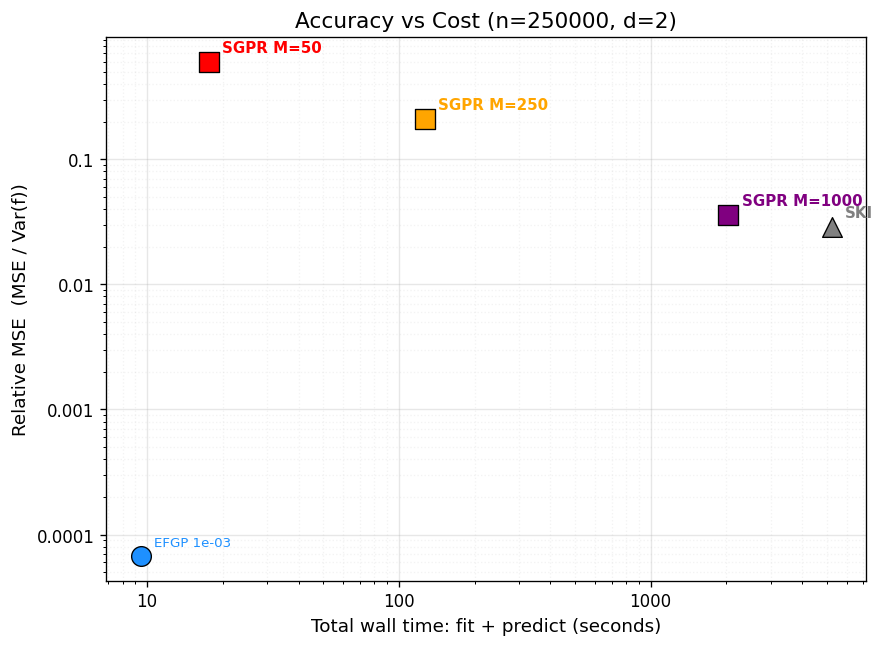

In [ ]:
# --- log Relative MSE vs log total time (fit + predict) ---
import matplotlib.ticker as ticker

f_var = float(f_test_true.var())

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# EFGP sweep: connected curve, colored by EPSILON
efgp_eps_sorted = sorted(efgp_results_big.keys(), reverse=True)  # large eps -> small eps
efgp_times = [efgp_results_big[e]['fit_time'] + efgp_results_big[e]['pred_time']
              for e in efgp_eps_sorted]
efgp_rel_mses = [efgp_results_big[e]['mse'] / f_var for e in efgp_eps_sorted]

ax.plot(efgp_times, efgp_rel_mses, '-', color='dodgerblue', linewidth=1.5,
        alpha=0.7, zorder=5)
for e, t, rm in zip(efgp_eps_sorted, efgp_times, efgp_rel_mses):
    ax.scatter(t, rm, s=140, color='dodgerblue', marker='o',
               edgecolors='black', linewidths=0.8, zorder=10)
    ax.annotate(f'EFGP {e:.0e}', (t, rm), textcoords='offset points',
                xytext=(8, 6), fontsize=8, color='dodgerblue')

# SKI point
ski_total_time = ski_time_big + ski_pred_time
ski_rel_mse = ski_mse / f_var
ax.scatter(ski_total_time, ski_rel_mse, s=140, color='gray', marker='^',
           edgecolors='black', linewidths=0.8, zorder=10)
ax.annotate('SKI', (ski_total_time, ski_rel_mse), textcoords='offset points',
            xytext=(8, 6), fontsize=9, fontweight='bold', color='gray')

# SGPR points
sgpr_colors = ['red', 'orange', 'purple', 'brown']
for (m, mse), c in zip(sgpr_mses.items(), sgpr_colors):
    t = sgpr_results_big[m]['fit_time_sec'] + sgpr_pred_times[m]
    rm = mse / f_var
    ax.scatter(t, rm, s=140, color=c, marker='s',
               edgecolors='black', linewidths=0.8, zorder=10)
    ax.annotate(f'SGPR M={m}', (t, rm), textcoords='offset points',
                xytext=(8, 6), fontsize=9, fontweight='bold', color=c)

ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))

ax.set_xlabel('Total wall time: fit + predict (seconds)', fontsize=11)
ax.set_ylabel('Relative MSE  (MSE / Var(f))', fontsize=11)
ax.set_title(f'Accuracy vs Cost (n={n_big}, d={d})', fontsize=13)

ax.grid(True, which='major', alpha=0.3, linestyle='-')
ax.grid(True, which='minor', alpha=0.15, linestyle=':')
fig.tight_layout()
plt.show()

In [ ]:
y_big.abs().mean()

tensor(0.8197, dtype=torch.float64)

## Posterior Mean Comparison: EFGP vs SGPR M=50

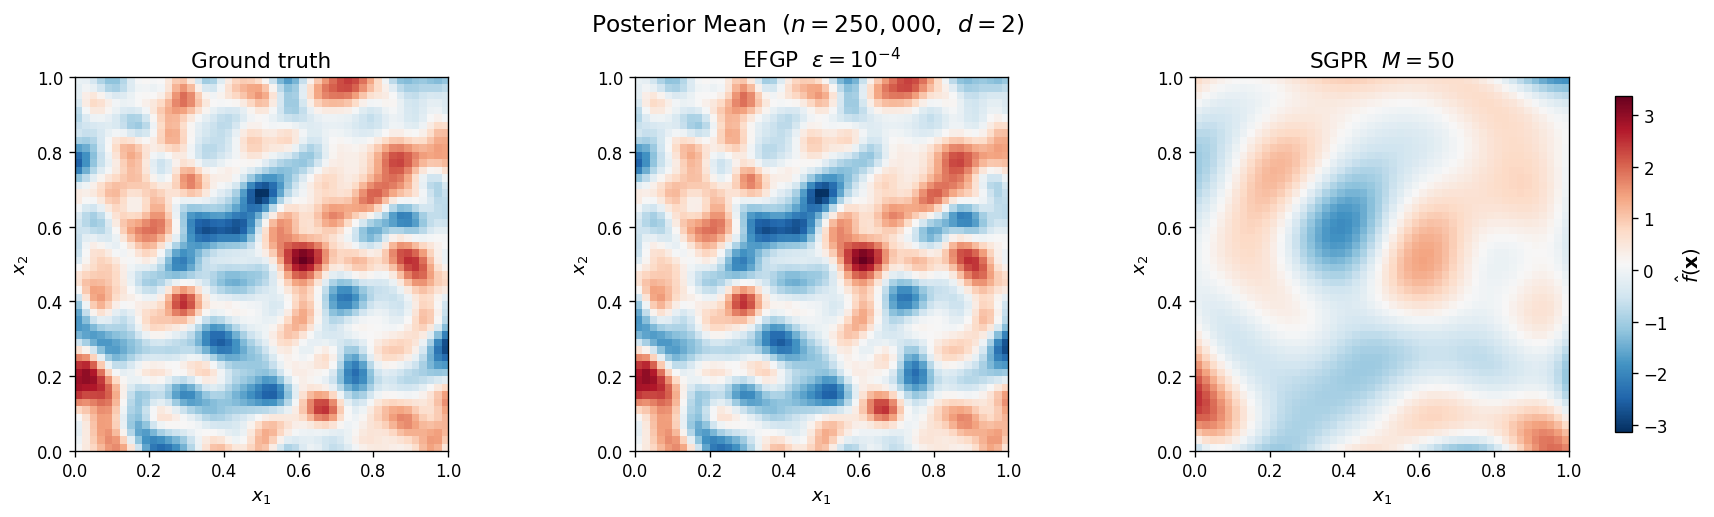

In [ ]:
# --- Posterior mean: Ground truth vs EFGP (eps=1e-4) vs SGPR (M=50) ---
shape = (n_test_per_dim, n_test_per_dim)
extent = [0, 1, 0, 1]

# Ground truth posterior mean
truth_grid = f_test_true.detach().reshape(shape).numpy()

# EFGP eps=1e-4 posterior mean (already computed in cell 24)
efgp_mean = efgp_results_big[1e-3]['mean']
efgp_grid = efgp_mean.detach().reshape(shape).numpy()

# SGPR M=50 posterior mean
sgpr_50 = sgpr_results_big[50]
sgpr_50['model'].eval(); sgpr_50['likelihood'].eval()
with torch.no_grad():
    sgpr_50_pred = sgpr_50['likelihood'](sgpr_50['model'](x_test.to(torch.float32)))
    sgpr_50_mean = sgpr_50_pred.mean.to(dtype=dtype)
sgpr_50_grid = sgpr_50_mean.detach().reshape(shape).numpy()

vmin = min(truth_grid.min(), efgp_grid.min(), sgpr_50_grid.min())
vmax = max(truth_grid.max(), efgp_grid.max(), sgpr_50_grid.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

im0 = axes[0].imshow(truth_grid.T, origin='lower', extent=extent,
                      vmin=vmin, vmax=vmax, cmap='RdBu_r', aspect='equal')
axes[0].set_title('Ground truth', fontsize=13)

im1 = axes[1].imshow(efgp_grid.T, origin='lower', extent=extent,
                      vmin=vmin, vmax=vmax, cmap='RdBu_r', aspect='equal')
axes[1].set_title(r'EFGP  $\varepsilon = 10^{-4}$', fontsize=13)

im2 = axes[2].imshow(sgpr_50_grid.T, origin='lower', extent=extent,
                      vmin=vmin, vmax=vmax, cmap='RdBu_r', aspect='equal')
axes[2].set_title(r'SGPR  $M = 50$', fontsize=13)

cb = fig.colorbar(im0, ax=axes.tolist(), shrink=0.9, pad=0.02)
cb.set_label(r'$\hat{f}(\mathbf{x})$', fontsize=12)

for ax in axes:
    ax.set_xlabel(r'$x_1$', fontsize=11)
    ax.set_ylabel(r'$x_2$', fontsize=11)

fig.suptitle(
    f'Posterior Mean  ($n = {n_big:,}$,  $d = {d}$)',
    fontsize=14,
)
plt.savefig('posterior_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
